In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes
import statsmodels.api as sm
np.random.seed(42)


# Regularization in Linear Regression

## 1. Problem
Predict diabetes progression one year after baseline from 10 clinical measurements.
442 patients. Target y ranges 25–346, higher = worse.

Features include age, sex, bmi, bp, and six blood serum measurements (s1–s6).
The serum features are biologically correlated — cholesterol fractions move together.
This correlation breaks OLS. Regularization is the fix.

In [ ]:
diabetes   = load_diabetes()
X, y       = diabetes.data, diabetes.target
feat_names = list(diabetes.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training: {X_train_s.shape[0]} patients  |  Test: {X_test_s.shape[0]} patients")

Training: 353 patients  |  Test: 89 patients


## 2. Model

All three methods fit a linear model. They differ only in what they minimize.

**OLS:**    minimize  ||y − Xβ||²                (no constraint)
**Ridge:**  minimize  ||y − Xβ||² + λ||β||²      (L2 penalty)
**Lasso:**  minimize  ||y − Xβ||² + λ||β||₁      (L1 penalty)

λ controls how hard we shrink coefficients.
- L2 shrinks smoothly — all features stay in the model
- L1 shrinks to exactly zero — automatic feature selection

**Best Subset Selection** (ISLR Algorithm 6.1):
Try every possible combination of features — 1,023 models.
Pick the best using AIC and BIC.
Exhaustive gold standard. Our benchmark for whether Lasso finds the right answer.

In [ ]:
# Candidate λ values — 200 on log scale from 0.001 to 10,000
lambdas = np.logspace(-3, 4, 200)

# Find best λ for Ridge via 5-fold cross-validation
ridge_cv     = RidgeCV(alphas=lambdas, cv=5).fit(X_train_s, y_train)
lambda_ridge = ridge_cv.alpha_

# Find best λ for Lasso via 5-fold cross-validation
lasso_cv     = LassoCV(alphas=lambdas, cv=5, max_iter=10000,
                       random_state=42).fit(X_train_s, y_train)
lambda_lasso = lasso_cv.alpha_

print(f"Ridge optimal λ: {lambda_ridge:.4f}")
print(f"Lasso optimal λ: {lambda_lasso:.4f}")

# Refit with the winning λ
ols   = LinearRegression().fit(X_train_s, y_train)
ridge = Ridge(alpha=lambda_ridge).fit(X_train_s, y_train)
lasso = Lasso(alpha=lambda_lasso, max_iter=10000).fit(X_train_s, y_train)

Ridge optimal λ: 40.5546
Lasso optimal λ: 1.5886


In [ ]:
def best_subset_selection(X_tr, y_tr, X_te, y_te, names):
    p, results = X_tr.shape[1], []
    for k in range(1, p + 1):
        best_rss, best_entry = np.inf, None
        for combo in combinations(range(p), k):
            X_sub_c = sm.add_constant(X_tr[:, combo])
            fit     = sm.OLS(y_tr, X_sub_c).fit()
            rss     = float(np.sum(fit.resid ** 2))
            if rss < best_rss:
                best_rss = rss
                X_te_sub = sm.add_constant(X_te[:, combo], has_constant='add')
                best_entry = {
                    'k': k, 'combo': combo,
                    'feat_names': [names[i] for i in combo],
                    'aic': fit.aic, 'bic': fit.bic,
                    'test_mse': mean_squared_error(y_te, fit.predict(X_te_sub)),
                }
        results.append(best_entry)
    best_aic = min(results, key=lambda x: x['aic'])
    best_bic = min(results, key=lambda x: x['bic'])
    return results, best_aic, best_bic

bss_results, best_aic, best_bic = best_subset_selection(
    X_train_s, y_train, X_test_s, y_test, feat_names
)

# Collect test MSE and feature count for all 5 methods
models  = {'OLS': ols, 'Ridge': ridge, 'Lasso': lasso}
metrics = {n: {
    'test_mse': mean_squared_error(y_test, m.predict(X_test_s)),
    'nonzero':  int(np.sum(m.coef_ != 0)),
    'coef':     m.coef_.copy(),
} for n, m in models.items()}

print(f"Best Subset (AIC): k={best_aic['k']}, features={best_aic['feat_names']}")
print(f"Best Subset (BIC): k={best_bic['k']}, features={best_bic['feat_names']}")
print(f"Lasso selected:    {[feat_names[i] for i in np.where(lasso.coef_ != 0)[0]]}")

Best Subset (AIC): k=6, features=['sex', 'bmi', 'bp', 's1', 's2', 's5']
Best Subset (BIC): k=6, features=['sex', 'bmi', 'bp', 's1', 's2', 's5']
Lasso selected:    ['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']


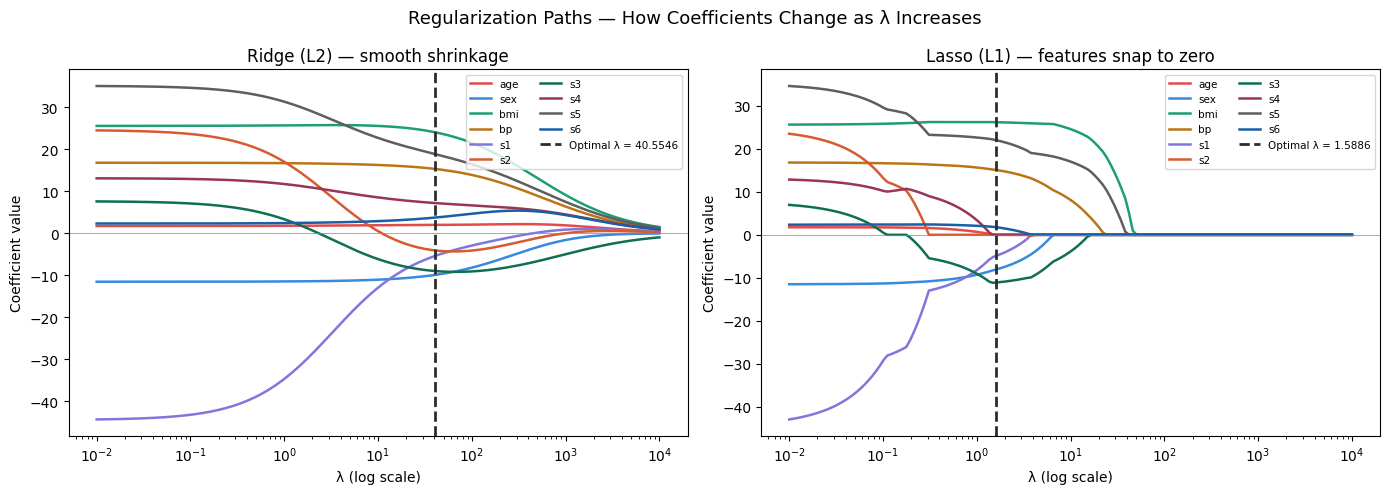

In [ ]:
lambdas_path = np.logspace(-2, 4, 150)
ridge_path   = np.array([Ridge(alpha=a).fit(X_train_s, y_train).coef_ for a in lambdas_path])
lasso_path   = np.array([Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train).coef_ for a in lambdas_path])

feat_colors = ['#E24B4A','#378ADD','#1D9E75','#BA7517','#7F77DD',
               '#D85A30','#0F6E56','#993556','#5F5E5A','#185FA5']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Regularization Paths — How Coefficients Change as λ Increases", fontsize=13)

for ax, path, opt_lam, title in [
    (ax1, ridge_path, lambda_ridge, 'Ridge (L2) — smooth shrinkage'),
    (ax2, lasso_path, lambda_lasso, 'Lasso (L1) — features snap to zero'),
]:
    for j, (feat, fc) in enumerate(zip(feat_names, feat_colors)):
        ax.semilogx(lambdas_path, path[:, j], color=fc, linewidth=1.8, label=feat)
    ax.axvline(opt_lam, color='#2C2C2A', linestyle='--', linewidth=2,
               label=f'Optimal λ = {opt_lam:.4f}')
    ax.axhline(0, color='#888780', linewidth=0.5)
    ax.set_xlabel('λ (log scale)'); ax.set_ylabel('Coefficient value')
    ax.set_title(title); ax.legend(fontsize=7.5, loc='upper right', ncol=2)

plt.tight_layout(); plt.show()

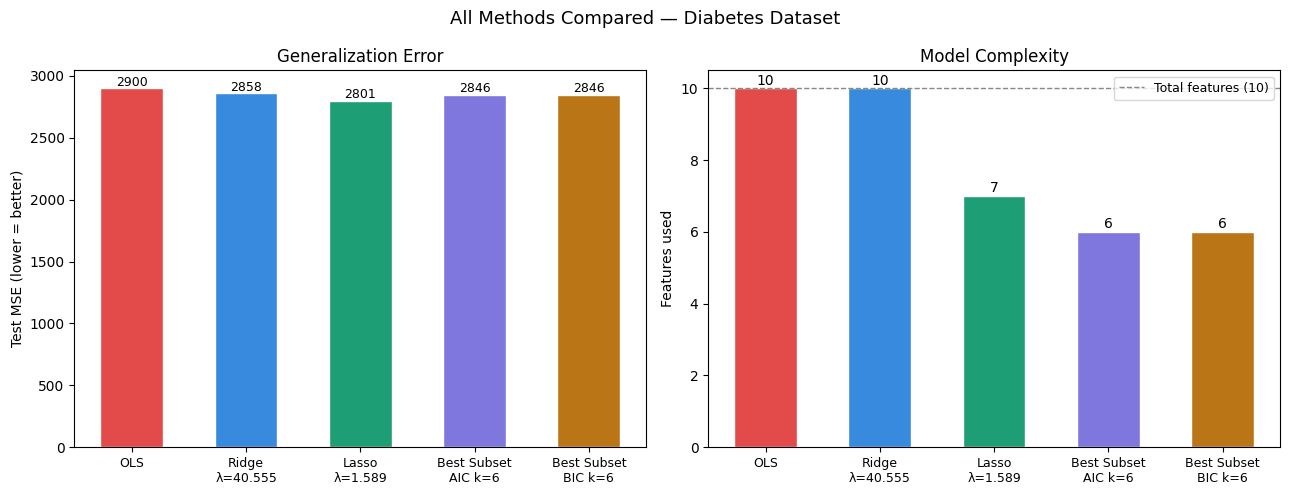

In [ ]:
method_labels = [
    'OLS',
    f'Ridge\nλ={lambda_ridge:.3f}',
    f'Lasso\nλ={lambda_lasso:.3f}',
    f'Best Subset\nAIC k={best_aic["k"]}',
    f'Best Subset\nBIC k={best_bic["k"]}',
]
all_mses = [metrics['OLS']['test_mse'], metrics['Ridge']['test_mse'],
            metrics['Lasso']['test_mse'], best_aic['test_mse'], best_bic['test_mse']]
all_nz   = [metrics['OLS']['nonzero'], metrics['Ridge']['nonzero'],
            metrics['Lasso']['nonzero'], best_aic['k'], best_bic['k']]
bar_colors = ['#E24B4A','#378ADD','#1D9E75','#7F77DD','#BA7517']
x = np.arange(len(method_labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("All Methods Compared — Diabetes Dataset", fontsize=13)

bars1 = ax1.bar(x, all_mses, color=bar_colors, width=0.55, edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(method_labels, fontsize=9)
ax1.set_ylabel("Test MSE (lower = better)")
ax1.set_title("Generalization Error")
for b, v in zip(bars1, all_mses):
    ax1.text(b.get_x() + b.get_width()/2, v + 20, f'{v:.0f}',
             ha='center', fontsize=9)

bars2 = ax2.bar(x, all_nz, color=bar_colors, width=0.55, edgecolor='white')
ax2.axhline(10, color='#888780', linestyle='--', linewidth=1,
            label='Total features (10)')
ax2.set_xticks(x); ax2.set_xticklabels(method_labels, fontsize=9)
ax2.set_ylabel("Features used")
ax2.set_title("Model Complexity")
ax2.legend(fontsize=9)
for b, v in zip(bars2, all_nz):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.1, str(v),
             ha='center', fontsize=10)

plt.tight_layout(); plt.show()

#Works Cited


# Acknowledgments of Assistance

Claude. Assistance given to the author, CDT Zander Bos. I used the following prompts in Claude, continuing from prior conversations about MA289 Project 3 on regularization: "I have to present the research, given some feedback when I presented the Google Colab of the Project 3 that you gave me. Help me to transform that Project 3 into the following parameters: it should follow this order: Process of Solving the Problem — 1. Problem/Data, 2. Model (Using a linear model, Ridge Lasso which are OLS, then compare Best Subset with the other models), 3. Error, 4. Optimization. For the Presentation: Present a Notebook, Only Real Data, Code a little bit to show understanding, do the code that finds the parameters for the models, Comparing the Results from Ridge and Lasso versus Best Subset (AIC and BIC), Only Interesting Results, Standardize Lambda and Alpha to show understanding (Code this by myself but for now I want you to show me what this would look like)," followed by clarifying responses specifying test MSE, prebuilt code with live hyperparameter coding, consistent λ notation, and instructor-selected interesting results; "Help me understand all of the clinical features"; "I want you to make the part I'm presenting a lot shorter, so I can give a decent explanation in 10 minutes or so"; "Create a works cited"; "Could you create a visualization for the diabetes dataset before we do anything with it"; "How are they measuring diabetes progression"; "Explain what this means: ridge_cv = RidgeCV(alphas=lambdas, cv=5).fit(X_train_s, y_train); lambda_ridge = ridge_cv.alpha_"; "What does this mean: ols = LinearRegression().fit(X_train_s, y_train); ridge = Ridge(alpha=lambda_ridge).fit(X_train_s, y_train); lasso = Lasso(alpha=lambda_lasso, max_iter=10000).fit(X_train_s, y_train)"; and "What do these lines theoretically do." The prompts returned a restructured eight-cell presentation notebook following the Problem–Model–Error–Optimization framework using only the sklearn diabetes dataset with consistent λ notation throughout, explanations of the ten clinical features (age, sex, bmi, bp, and the six serum measurements s1 through s6) including their biological meaning and correlation structure, two exploratory data visualizations (a feature correlation heatmap highlighting the s1–s6 collinearity and a target distribution figure with scatter plots of the strongest individual predictors), a Chicago-style works cited list including the Efron et al. 2004 diabetes dataset paper, the ISLR textbook for Algorithm 6.1, the Tibshirani 1996 Lasso paper, the Hoerl and Kennard 1970 Ridge paper, and software citations for scikit-learn and statsmodels, a clarification of what the disease progression target actually measures and how to honestly describe it in the presentation, and line-by-line conceptual explanations of the cross-validation code that finds optimal λ values and the model refitting step. The notebook structure, figure design, and analytical framework informed the construction of my presentation notebook. All written markdown cells, verbal explanations delivered during the presentation, and analytical conclusions in my report were my own, informed by but not taken verbatim from these responses. I verified the sklearn and statsmodels implementations, cross-validation procedures, and mathematical formulations against course materials and documentation. Anthropic, (https://claude.ai/share/335d389e-70ff-4fc3-9405-c3dfbb5e0d46). West Point, NY, 22APR2026.
